In [1]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../../../'))
sys.path.insert(0, src_dir)
import src
# plt.style.use('../../../foresight.mplstyle')


/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from jax.lib import xla_bridge
import jax
print(xla_bridge.get_backend().platform)
# name = "cuDNN"
jax._src.lib.cuda_versions.cudnn_get_version()
# jax._src.lib.cuda_versions.cudnn_build_version()
jax.default_device = jax.devices("gpu")[0]

gpu


In [ ]:
from src.models.FNS import FNScircuit
# * Construct, takes around 3 minutes
FNSnet = FNScircuit(rho = 30000, nu = 10, n_ext = 100, J_e = 0.0007, delta=8, key=jax.random.PRNGKey(42),
        p_ee=0.15,  # Maximum connection probability (Campagnola2022, corrected)
        p_ei=0.4,
        p_ie=0.5,
        p_ii=0.3,
        sigma_ee=0.125,  # Width of the distance-dependent connectivity kernel (mm)
        sigma_ei=0.1,
        sigma_ie=0.1*2,
        sigma_ii=0.125*2)
# ! Chosen these parameters based on layer 2/3 connectivity parameters found via https://aisynphys.readthedocs.io/en/latest/matrix_analyzer.html#matrix-analyzer
# For biological plausability, n_ext should be about 10% of the in-degree and nu should be
# ? Note that around 10% of synapses tend to be external feed-forward... check... cite...
# no more than a dozen or so???
# FNSnet = FNScircuit(rho=30000, nu=275.0, n_ext = 30, J_e=0.0005, delta=18)

/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/brainpy/_src/dyn/others/input.py:212: UserWarning: 
  warnings.warn('')


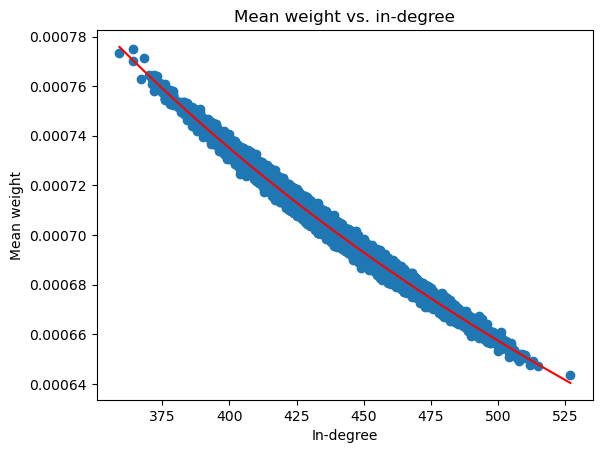

E2E in-degree: 440.8 (mean), 441.8 (expected)
E2I in-degree: 564.1 (mean), 565.5 (expected)
I2E in-degree: 917.0 (mean), 942.5 (expected)
I2I in-degree: 803.8 (mean), 883.6 (expected)


In [4]:
def mean_weights(proj):
    """
    Calculate the mean input weight for each postsynaptic neuron.
    That is, for each post-syn index i, we compute:
        mean_weights[i] = (sum of weights of all edges leading to i) / (number of edges leading to i).
    """
    # Number of post-synaptic neurons
    M = jnp.prod(jnp.array(proj.post.size))

    # 'indices' is a 1D array listing which post-syn neuron each edge connects to
    indices = jnp.array(proj.comm.indices)
    # 'weight' holds the corresponding weight for each edge in the same order
    weights = jnp.array(proj.comm.weight)

    # 1) in-degree count: how many edges lead to each post-syn i
    in_degs = jnp.bincount(indices, length=M)

    # 2) sum of weights leading to each post-syn i
    sum_w = jnp.bincount(indices, weights=weights, length=M)

    # 3) safely divide sum_w[i] by in_degs[i], handling the case in_degs[i] = 0
    mean_w = jnp.where(in_degs > 0, sum_w / in_degs, 0.0)
    return mean_w
mean_ws = mean_weights(FNSnet.E2E.proj)
ks = src.models.FNS.indegrees(FNSnet.E2E.proj)
plt.scatter(ks, mean_ws)
a, b = np.polyfit(1/np.sqrt(ks), mean_ws, 1)
sks = np.sort(ks)
plt.plot(sks, a/np.sqrt(sks) + b, 'r')
plt.xlabel('In-degree')
plt.ylabel('Mean weight')
plt.title('Mean weight vs. in-degree')
plt.show()


k = src.models.FNS.indegree(FNSnet.E2E.proj)
k_hat = src.models.FNS.expected_indegree(FNSnet, "ee")
print(f"E2E in-degree: {k:.1f} (mean), {k_hat:.1f} (expected)")
k = src.models.FNS.indegree(FNSnet.E2I.proj)
k_hat = src.models.FNS.expected_indegree(FNSnet, "ei")
print(f"E2I in-degree: {k:.1f} (mean), {k_hat:.1f} (expected)")
k = src.models.FNS.indegree(FNSnet.I2E.proj)
k_hat = src.models.FNS.expected_indegree(FNSnet, "ie")
print(f"I2E in-degree: {k:.1f} (mean), {k_hat:.1f} (expected)")
k = src.models.FNS.indegree(FNSnet.I2I.proj)
k_hat = src.models.FNS.expected_indegree(FNSnet, "ii")
print(f"I2I in-degree: {k:.1f} (mean), {k_hat:.1f} (expected)")



In [5]:
FNSnet.reinit_weights(5)
FNSnet.reinit_nu(28)
bp.reset_state(FNSnet) # Resets all things recursively, unlike FNSnet.reset_state()

# * No per-neuron balance
# ! xx No common-neighbour property
# ! xx No reverse pooling or lognormal coupling weights

# * Simulate
I = np.array(FNSnet.E.V.value)
I[:] = 0.0
i = I.reshape(*FNSnet.E.size)
i[0:25, 0:25] = 0.0

runner = bp.DSRunner(FNSnet, monitors=['E.V', 'I.V', 'E.spike', 'I.spike'])# , inputs = [('Ein.input', I)])
runner.run(duration=3000.)

# t = runner.mon['ts'].view()
# X = runner.mon['E.spike'].view()

Predict 30000 steps: :   0%|          | 0/30000 [00:00<?, ?it/s]

Predict 30000 steps: : 100%|██████████| 30000/30000 [00:28<00:00, 1044.48it/s]


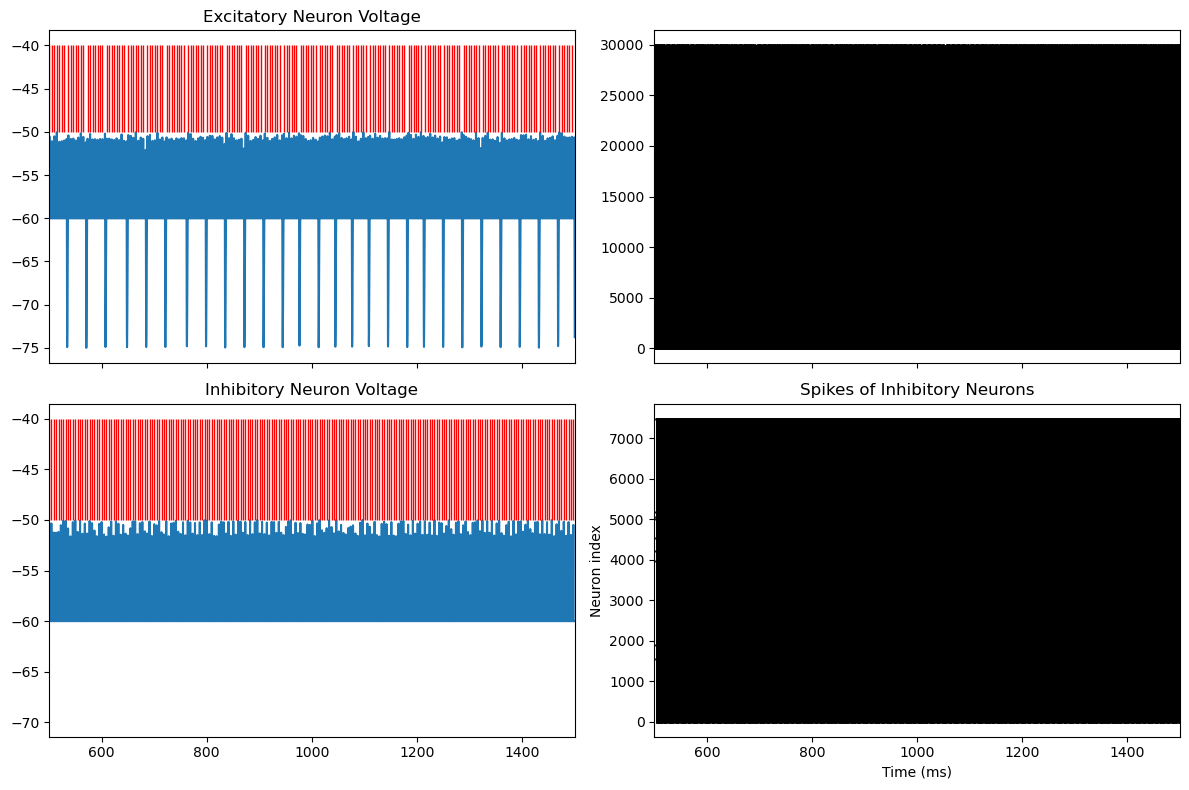

In [6]:
# bp.visualize.raster_plot(t, X, title='Spikes of Excitatory Neurons', show=True)
%matplotlib inline
from src.plots import animate_spiking_activity
from IPython.display import HTML
ani = animate_spiking_activity(FNSnet, runner, ms_per_s=100, fps=12, window_size_ms=50, tstart=1000)

ani.save("spiking_activity.mp4", writer="ffmpeg")
# HTML(ani.to_jshtml())

i = 2000
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
x = runner.mon['E.V'].view()[:, i]
spikes = np.where(runner.mon['E.spike'].view()[:, i])
axs[0, 0].plot(runner.mon['ts'].view(), x)
spike_times = runner.mon['ts'][spikes]
axs[0, 0].vlines(spike_times, FNSnet.E.V_th, FNSnet.E.V_th + 10,
                  color='r', linewidth=1)
axs[0, 0].set_title('Excitatory Neuron Voltage')
x = runner.mon['I.V'].view()[:, i]
spikes = np.where(runner.mon['I.spike'].view()[:, i])
axs[1, 0].plot(runner.mon['ts'].view(), x)
spike_times = runner.mon['ts'][spikes]
axs[1, 0].vlines(spike_times, FNSnet.E.V_th, FNSnet.E.V_th + 10,
                  color='r', linewidth=1)
axs[1, 0].set_title('Inhibitory Neuron Voltage')
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["E.spike"],
                           ax=axs[0, 1],
                           title="Spikes of Excitatory Neurons")
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["I.spike"],
                           ax=axs[1, 1],
                           title="Spikes of Inhibitory Neurons",
                           xlim=(500, 1500))
plt.tight_layout()
plt.show()

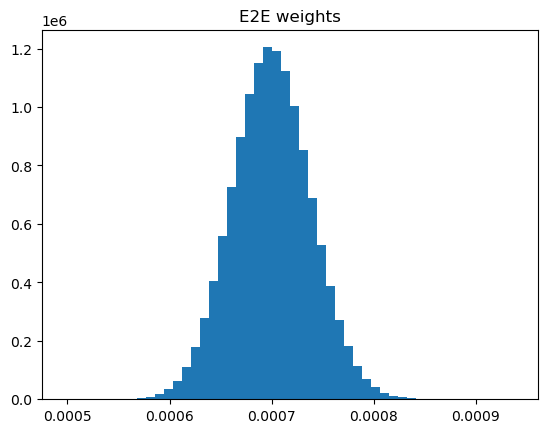

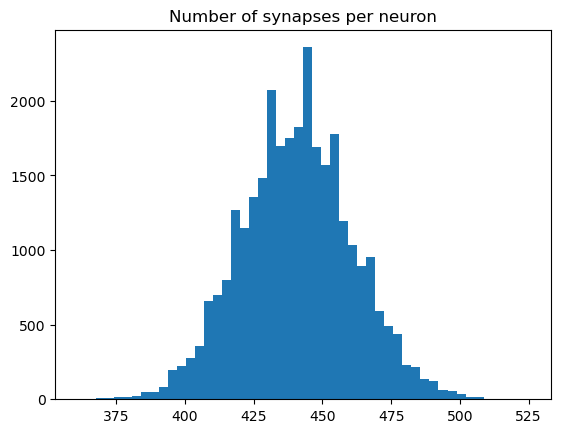

In [7]:
# * First, plot the current distribution of synaptic weights
ws = FNSnet.E2E.proj.comm.weight
plt.hist(ws, bins=50)
plt.gca().set_title('E2E weights')

# * And the number of synapses per neuron
plt.figure()
plt.hist(np.diff(FNSnet.E2E.proj.comm.indptr), bins=50) # ! Check !!!
plt.gca().set_title('Number of synapses per neuron')
plt.show()

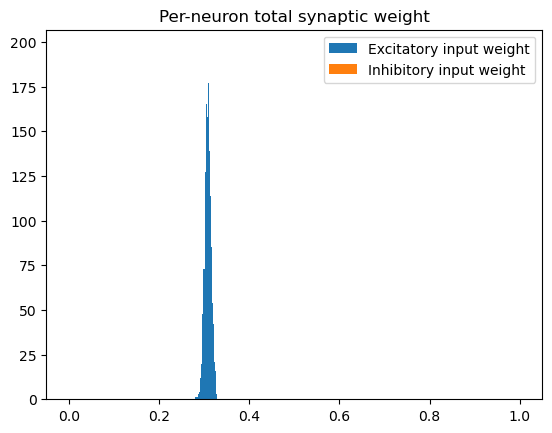

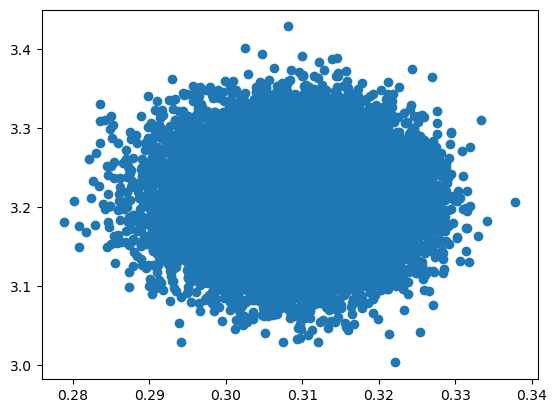

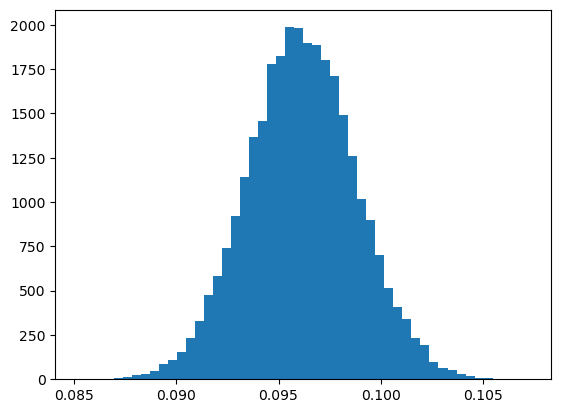

In [8]:
# * Calculate the per-neuron EI balance
# DONT USE REQUIRES, SINCE THAT REBUILDS THE ARRAY
# ? How to peroperly check the balance of weights?
I2E = bp.connect.csr2coo((FNSnet.I2E.proj.comm.indices, FNSnet.I2E.proj.comm.indptr))
E2E = bp.connect.csr2coo((FNSnet.E2E.proj.comm.indices, FNSnet.E2E.proj.comm.indptr))
w_I2E = FNSnet.I2E.proj.comm.weight
w_E2E = FNSnet.E2E.proj.comm.weight
assert len(I2E[0]) == len(w_I2E)

Ne = np.prod(FNSnet.E.size)
sum_exc = np.bincount(E2E[1], weights=w_E2E, minlength=Ne)
sum_inh = np.bincount(I2E[1], weights=w_I2E, minlength=Ne)
bins = np.arange(0, 1, 0.0001)
plt.hist(sum_exc, bins=bins, label="Excitatory input weight")
plt.hist(sum_inh, bins=bins, label="Inhibitory input weight")
plt.legend()
plt.title("Per-neuron total synaptic weight")
plt.show()

plt.scatter(sum_exc, sum_inh)
plt.show()

plt.hist(sum_exc/sum_inh, bins=50)
plt.show()
